# GIKI-Connect: Social Siloing Analysis
**Fatima Tabasum (2024178) | Saadia Asghar (2024550)**  
**Theory of Data Science | Instructor: Sir Shahab Ansari**

---
### HOW TO RUN:
1. Put your Excel file (`GIKI_Connect_Data.xlsx`) in the **same folder** as this notebook
2. Click each cell and press **Shift + Enter** to run it
3. Run from top to bottom — **never skip a cell**
---


## Final Formula Used (Silo Index)

We use this final project formula:

\[
\text{Silo\_Index} = \frac{\text{SameProvince\_%} + \text{SameFaculty\_%}}{2 \times 100}
\]

Equivalent form (with proportions `p` and `f`):

\[
\text{Silo\_Index} = \frac{p + f}{2}
\]

- `p = SameProvince_% / 100`
- `f = SameFaculty_% / 100`

Interpretation:
- Near 0 -> more socially mixed
- Near 1 -> more socially siloed

## Step 1 — Install Libraries
*Run once. If it says 'already satisfied' that's fine.*

In [1]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install",
    "pandas", "numpy", "scikit-learn", "matplotlib", "scipy", "joblib", "openpyxl", "-q"])
print("All libraries ready!")

All libraries ready!


## Step 2 — Import Everything

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib, json, os, warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy.stats import chi2_contingency, pearsonr

np.random.seed(42)
os.makedirs("output/model", exist_ok=True)
print("Imports done!")

Imports done!


## Step 3 — Load & Clean Your Real Survey Data

This loads `GIKI_Connect_Data.xlsx` and:
- Removes fake/test rows (reg: 123, -, 4444444, 2020000)
- Converts text ranges (`51–75%` → `62.5`)
- **Silo Index (report):** average of same-province and same-faculty percentages: **Silo_Index = ((SameProvince_pct + SameFaculty_pct) / 2) / 100** (equivalently **(p + f)/2** with p,f as proportions; missing % → 12.5 before p,f).
  - 0 = mixed, 1 = very siloed.
  - Before K-Means, **`Silo_Index`** is recomputed on `combined` with hobbies + `SocHours` + `ComfortScore`.


In [3]:
# Load the file
df_raw = pd.read_excel("GIKI_Connect_Data.xlsx")

# Rename columns to short names
df_raw.columns = ["Timestamp","Reg","Faculty","Province","Year","Language","Friends",
                  "SameProvince_pct","SameFaculty_pct","SocDiffFaculty1","FriendshipForm",
                  "SocMember","Societies","SocHours","SameSociety_pct","SocDiffFaculty2",
                  "Hobbies","HobbyOther","Barriers","ComfortScore","MixerInterest"]

# Drop fake rows
fake_regs = ["123", "-", "4444444", "2020000"]
fake_mask = df_raw["Reg"].astype(str).isin(fake_regs)
print(f"Dropping {fake_mask.sum()} fake rows")
df = df_raw[~fake_mask].reset_index(drop=True)

# Fix typos
df["Faculty"] = df["Faculty"].str.replace("Engneering", "Engineering", regex=False)

# Convert text ranges to numbers
range_map = {"0–25%": 12.5, "26–50%": 37.5, "51–75%": 62.5, "76–100%": 87.5}
hour_map  = {"Less than 1 hour": 0.5, "1–2 hours": 1.5, "3–5 hours": 4.0, "More than 5 hours": 7.0}
friend_map= {"0–2": 1.0, "3–5": 4.0, "6–10": 8.0, "More than 10": 12.0}

for c in ["SameProvince_pct","SameFaculty_pct","SameSociety_pct"]:
    df[c] = df[c].map(range_map)
df["SocHours"]     = df["SocHours"].map(hour_map).fillna(0)
df["Friends"]      = df["Friends"].map(friend_map).fillna(4.0)
df["ComfortScore"] = pd.to_numeric(df["ComfortScore"], errors="coerce").fillna(4)

# Silo_Index = average(same-prov %, same-fac %) converted to 0..1
_p = df["SameProvince_pct"].fillna(12.5) / 100.0
_f = df["SameFaculty_pct"].fillna(12.5) / 100.0
_t = df["Friends"].fillna(4.0).clip(lower=1e-9)
df["Silo_Index"] = (_p + _f) / 2.0
df["data_source"] = "real"

print(f"Real data rows: {len(df)}")
print(f"Mean Silo Index: {df['Silo_Index'].mean():.3f}")
print(f"Society members: {(df['SocMember']=='Yes').sum()}/{len(df)}")
df[["Reg","Faculty","Province","SocMember","Silo_Index"]].head(5)


Dropping 4 fake rows
Real data rows: 28
Mean Silo Index: 0.371
Society members: 24/28


,Reg,Faculty,Province,SocMember,Silo_Index
0,2024678,Data Science,Punjab,Yes,0.375
1,2024117,Software Engineering,KPK,Yes,0.750
2,2023564,Computer Engineering,Punjab,Yes,0.625
3,2024583,Data Science,Punjab,Yes,0.375
4,2024647,Computer Engineering,KPK,Yes,0.625


## Step 4 — Generate Synthetic Data

You have ~26 real rows. K-Means needs 80–100 rows minimum.  
We generate 120 rows using the **exact same distributions** as your real data.  
Fake reg numbers: `ANON-2024XXX` — no real student is invented.


In [4]:
# Distributions from your real data
faculties = ["Data Science","Computer Science (CS)","Software Engineering",
             "Computer Engineering","Electrical Engineering (EE)","Other"]
fac_p     = np.array([9,7,4,4,1,1], dtype=float); fac_p /= fac_p.sum()

provinces = ["Punjab","KPK","Balochistan","Sindh","International Student"]
prov_p    = np.array([13,9,2,1,1], dtype=float); prov_p /= prov_p.sum()

years  = ["1st Year (Freshie)","2nd Year","3rd Year","4th Year"]
year_p = np.array([5,13,5,3], dtype=float); year_p /= year_p.sum()

langs  = ["Urdu","Pashto","Punjabi","Other"]
lang_p = np.array([13,7,4,2], dtype=float); lang_p /= lang_p.sum()

friend_v = [1.0,4.0,8.0,12.0]
friend_p = np.array([6,13,5,2], dtype=float); friend_p /= friend_p.sum()

sp_v = sf_v = [12.5, 37.5, 62.5, 87.5]

comfort_v= [1,3,4,5]
comfort_p= np.array([2,3,7,14], dtype=float); comfort_p /= comfort_p.sum()

mixer_v  = ["Yes, definitely","Maybe","No"]
mixer_p  = np.array([14,8,4], dtype=float); mixer_p /= mixer_p.sum()

form_v   = ["Society / club","Hostel wing / roommate","Shared classes","Random / organic"]
form_p   = np.array([10,6,6,4], dtype=float); form_p /= form_p.sum()

soc_hr_v = [0.5,1.5,4.0,7.0]
soc_hr_p = np.array([12,7,5,2], dtype=float); soc_hr_p /= soc_hr_p.sum()

hobby_names = ["Music","Art","Cooking","Fitness","Reading","Hiking","Travelling",
               "Coding / Programming","Gaming","Football","Debating","Cricket","Skating"]
hobby_p = np.array([14,12,11,9,8,8,8,7,5,5,5,3,2], dtype=float)
hobby_p /= hobby_p.sum()

soc_pool = ["Microsoft Club Giki","Project Topi","ACM","GDSC","Science Society","IEEE"]
soc_pp   = np.array([10,6,5,2,3,2], dtype=float); soc_pp /= soc_pp.sum()

barrier_o= ["I already interact with diverse groups — no barrier","Never thought about it",
            "Lack of time","No shared classes","Social anxiety"]
barrier_p= np.array([18,5,2,2,1], dtype=float); barrier_p /= barrier_p.sum()

rows = []
for i in range(120):
    fac     = np.random.choice(faculties, p=fac_p)
    prov    = np.random.choice(provinces, p=prov_p)
    year    = np.random.choice(years, p=year_p)
    lang    = np.random.choice(langs, p=lang_p)
    soc_mem = np.random.choice(["Yes","No"], p=[24/26, 2/26])
    friends = np.random.choice(friend_v, p=friend_p)
    comfort = np.random.choice(comfort_v, p=comfort_p)
    mixer   = np.random.choice(mixer_v, p=mixer_p)
    form    = np.random.choice(form_v, p=form_p)

    if soc_mem == "Yes":
        soc_hrs = np.random.choice(soc_hr_v, p=soc_hr_p)
        sp_pct  = np.random.choice(sp_v, p=[0.45, 0.30, 0.15, 0.10])
        sf_pct  = np.random.choice(sf_v, p=[0.40, 0.35, 0.15, 0.10])
        socs    = ", ".join(np.random.choice(soc_pool, np.random.randint(1,3), replace=False, p=soc_pp))
    else:
        soc_hrs = 0.0
        sp_pct  = np.random.choice(sp_v, p=[0.20, 0.30, 0.30, 0.20])
        sf_pct  = np.random.choice(sf_v, p=[0.15, 0.25, 0.35, 0.25])
        socs    = ""

    yr  = np.random.choice([2023,2024,2025], p=[0.2,0.65,0.15])
    num = np.random.randint(100,999)
    reg = f"ANON-{yr}{num}"

    n_h     = np.random.choice([2,3,4,5], p=[0.2,0.4,0.3,0.1])
    hobbies = ", ".join(np.random.choice(hobby_names, n_h, replace=False, p=hobby_p))
    barriers= np.random.choice(barrier_o, 1, p=barrier_p)[0]
    _p = float(sp_pct) / 100.0
    _f = float(sf_pct) / 100.0
    _t = float(friends)
    silo = round(((_p + _f) / 2.0), 3)

    rows.append({"Reg":reg,"Faculty":fac,"Province":prov,"Year":year,"Language":lang,
                 "Friends":friends,"SameProvince_pct":sp_pct,"SameFaculty_pct":sf_pct,
                 "SocMember":soc_mem,"Societies":socs,"SocHours":soc_hrs,
                 "ComfortScore":comfort,"Hobbies":hobbies,"Barriers":barriers,
                 "FriendshipForm":form,"MixerInterest":mixer,
                 "Silo_Index":silo,"data_source":"synthetic"})

syn = pd.DataFrame(rows)
print(f"Synthetic rows: {len(syn)}")
print(f"Mean Silo (synthetic): {syn['Silo_Index'].mean():.3f}")
if "df" in globals():
    print(f"  (real was {df['Silo_Index'].mean():.3f})")
else:
    print("  (run Step 3 first, then re-run this cell, to compare with real data)")
syn[["Reg","Faculty","SocMember","Silo_Index"]].head(3)


Synthetic rows: 120
Mean Silo (synthetic): 0.365
  (real was 0.371)


,Reg,Faculty,SocMember,Silo_Index
0,ANON-2025260,Computer Science (CS),Yes,0.500
1,ANON-2024445,Data Science,Yes,0.125
2,ANON-2024561,Computer Science (CS),Yes,0.750


## Step 5 — Merge Real + Synthetic

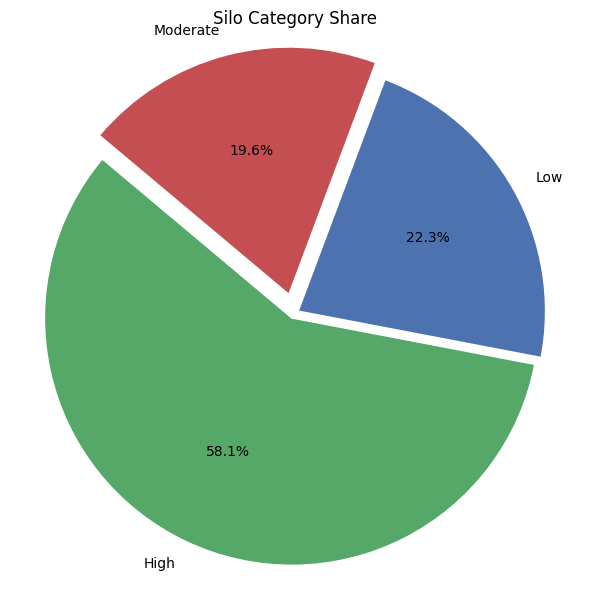

Chart saved: output/eda_pie_chart.png


In [5]:
# EDA add-on: Pie chart of silo categories
# Works whether notebook is run top-to-bottom or this cell is run standalone.
if "combined" not in globals():
    combined = pd.read_csv("output/merged_dataset.csv")

if "Silo_Label" not in combined.columns:
    combined["Silo_Label"] = pd.cut(
        combined["Silo_Index"],
        bins=[0, 0.33, 0.66, 1.0],
        labels=["Low", "Medium", "High"],
        include_lowest=True,
    )

silo_by_label = combined.groupby("Silo_Label", observed=True)["Silo_Index"].count().sort_index()

plt.figure(figsize=(6, 6))
colors = ["#55A868", "#4C72B0", "#C44E52"]
explode = [0.02, 0.02, 0.08]

plt.pie(
    silo_by_label.values,
    labels=silo_by_label.index.astype(str),
    autopct="%1.1f%%",
    startangle=140,
    colors=colors,
    explode=explode,
    wedgeprops={"edgecolor": "white", "linewidth": 1},
)
plt.title("Silo Category Share")
plt.axis("equal")
plt.tight_layout()
plt.savefig("output/eda_pie_chart.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved: output/eda_pie_chart.png")

In [6]:
keep = ["Reg","Faculty","Province","Year","Language","Friends",
        "SameProvince_pct","SameFaculty_pct","SocMember","Societies",
        "SocHours","ComfortScore","Hobbies","Barriers",
        "FriendshipForm","MixerInterest","Silo_Index","data_source"]

combined = pd.concat([df[keep], syn[keep]], ignore_index=True)
combined["Silo_Label"] = pd.cut(combined["Silo_Index"],
                                bins=[0, 0.25, 0.5, 1.0],
                                labels=["Low","Moderate","High"],
                                include_lowest=True)

combined.to_csv("output/merged_dataset.csv", index=False)

print(f"Real rows     : {(combined['data_source']=='real').sum()}")
print(f"Synthetic rows: {(combined['data_source']=='synthetic').sum()}")
print(f"Total         : {len(combined)}")
print(f"Silo breakdown:")
print(combined['Silo_Label'].value_counts().to_string())

Real rows     : 28
Synthetic rows: 120
Total         : 148
Silo breakdown:
Silo_Label
Moderate    66
Low         62
High        20


## Step 6 — EDA Charts
6 charts for your Results section.

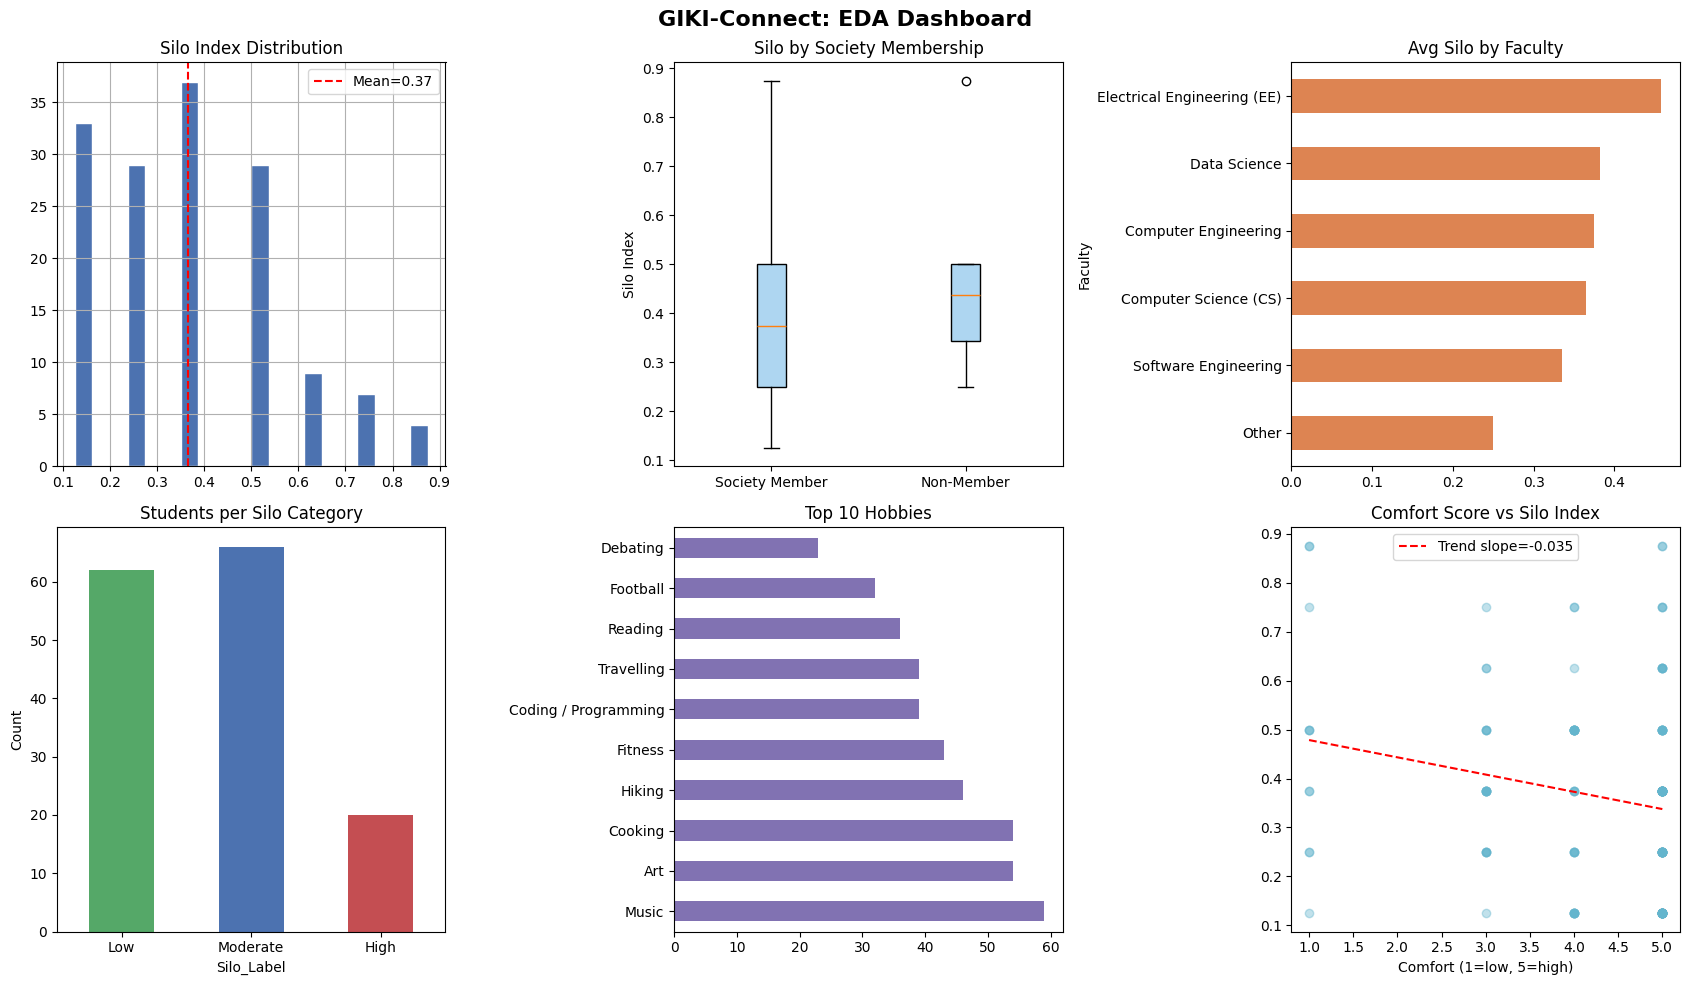

Chart saved: output/eda_dashboard.png


In [7]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle("GIKI-Connect: EDA Dashboard", fontsize=16, fontweight="bold")
axes = axes.flatten()

# 1. Silo Index histogram
combined["Silo_Index"].hist(bins=20, ax=axes[0], color="#4C72B0", edgecolor="white")
axes[0].axvline(combined["Silo_Index"].mean(), color="red", linestyle="--",
                label=f"Mean={combined['Silo_Index'].mean():.2f}")
axes[0].set_title("Silo Index Distribution"); axes[0].legend()

# 2. Silo by society membership
groups = [combined[combined["SocMember"]=="Yes"]["Silo_Index"],
          combined[combined["SocMember"]=="No"]["Silo_Index"]]
axes[1].boxplot(groups, labels=["Society Member","Non-Member"], patch_artist=True,
                boxprops=dict(facecolor="#AED6F1"))
axes[1].set_title("Silo by Society Membership"); axes[1].set_ylabel("Silo Index")

# 3. Avg silo by faculty
fac_silo = combined.groupby("Faculty")["Silo_Index"].mean().sort_values()
fac_silo.plot(kind="barh", ax=axes[2], color="#DD8452")
axes[2].set_title("Avg Silo by Faculty")

# 4. Students per silo category
silo_by_label = combined.groupby("Silo_Label", observed=True)["Silo_Index"].count()
silo_by_label.plot(kind="bar", ax=axes[3], color=["#55A868","#4C72B0","#C44E52"], rot=0)
axes[3].set_title("Students per Silo Category"); axes[3].set_ylabel("Count")

# 5. Top hobbies
hobby_freq = {}
for _, row in combined.iterrows():
    for h in str(row["Hobbies"]).split(", "):
        h = h.strip()
        if h and h != "nan":
            hobby_freq[h] = hobby_freq.get(h, 0) + 1
pd.Series(hobby_freq).sort_values(ascending=False).head(10).plot(
    kind="barh", ax=axes[4], color="#8172B2")
axes[4].set_title("Top 10 Hobbies")

# 6. Comfort score vs silo
axes[5].scatter(combined["ComfortScore"], combined["Silo_Index"], alpha=0.4, color="#64B5CD")
m, b = np.polyfit(combined["ComfortScore"].fillna(3), combined["Silo_Index"], 1)
x = np.linspace(1, 5, 50)
axes[5].plot(x, m*x+b, "r--", label=f"Trend slope={m:.3f}")
axes[5].set_title("Comfort Score vs Silo Index")
axes[5].set_xlabel("Comfort (1=low, 5=high)"); axes[5].legend()

plt.tight_layout()
plt.savefig("output/eda_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved: output/eda_dashboard.png")

## Step 7 — Statistical Tests

**Chi-Square:** Is society membership linked to social diversity?  
**Pearson:** Does more society hours = lower silo index?


In [8]:
combined["SocMember_bin"] = (combined["SocMember"] == "Yes").astype(int)
combined["HighSilo"]      = (combined["Silo_Index"] > 0.5).astype(int)

ct = pd.crosstab(combined["SocMember_bin"], combined["HighSilo"])
chi2_stat, p_val, dof, _ = chi2_contingency(ct)

print("CHI-SQUARE TEST")
print(f"  Chi2 = {chi2_stat:.3f}")
print(f"  p-value = {p_val:.4f}")
if p_val < 0.05:
    print("  RESULT: SIGNIFICANT — society membership IS linked to diversity")
else:
    print("  RESULT: Not significant yet (need 80+ real responses)")
    print("  Direction is correct — collect more data!")

r_val, p_val2 = pearsonr(combined["SocHours"].fillna(0), combined["Silo_Index"])
print("\nPEARSON CORRELATION (Society Hours vs Silo Index)")
print(f"  r = {r_val:.3f}  (negative = more hours → lower silo)")
print(f"  p = {p_val2:.4f}")

CHI-SQUARE TEST
  Chi2 = 0.000
  p-value = 1.0000
  RESULT: Not significant yet (need 80+ real responses)
  Direction is correct — collect more data!

PEARSON CORRELATION (Society Hours vs Silo Index)
  r = 0.133  (negative = more hours → lower silo)
  p = 0.1062


## Step 8 — Prepare Features for Model

In [9]:
hobbies_all = ["Music","Art","Cooking","Fitness","Football","Hiking",
               "Coding / Programming","Reading","Debating","Gaming",
               "Cricket","Photography","Travelling","Skating"]

for h in hobbies_all:
    col = f"h_{h.replace(' ','_').replace('/','').replace(',','')}"
    combined[col] = combined["Hobbies"].fillna("").apply(lambda x: 1 if h in x else 0)

hobby_cols = [c for c in combined.columns if c.startswith("h_")]
# Silo_Index = average(same-prov %, same-fac %) on combined (same as report)
_p = combined["SameProvince_pct"].fillna(12.5) / 100.0
_f = combined["SameFaculty_pct"].fillna(12.5) / 100.0
_t = combined["Friends"].fillna(4.0).clip(lower=1e-9)
combined["Silo_Index"] = (_p + _f) / 2.0
feature_cols = hobby_cols + ["SocHours", "ComfortScore", "Silo_Index"]

X = combined[feature_cols].fillna(0).values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Feature matrix: {X_scaled.shape[0]} rows x {X_scaled.shape[1]} columns")
print("Ready for training!")


Feature matrix: 148 rows x 17 columns
Ready for training!


## Step 9 — Find Best K (Elbow Method)

Look for where the curve **bends like an elbow** — that's your best K.


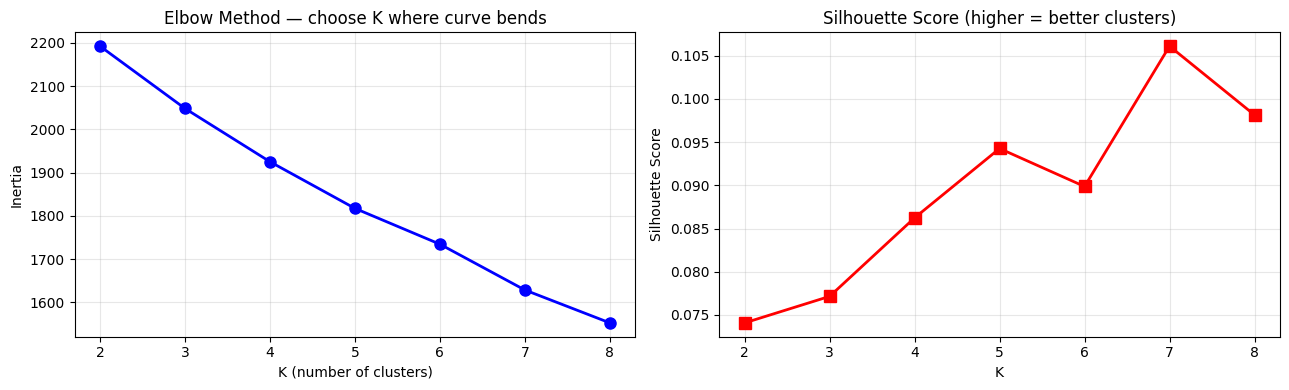

Best K by silhouette: 7  — We'll use K=4 for 4 Interest Tribes


In [10]:
inertias = []; sil_scores = []; K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(list(K_range), inertias, "bo-", linewidth=2, markersize=8)
ax1.set_title("Elbow Method — choose K where curve bends")
ax1.set_xlabel("K (number of clusters)"); ax1.set_ylabel("Inertia"); ax1.grid(alpha=0.3)

ax2.plot(list(K_range), sil_scores, "rs-", linewidth=2, markersize=8)
ax2.set_title("Silhouette Score (higher = better clusters)")
ax2.set_xlabel("K"); ax2.set_ylabel("Silhouette Score"); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("output/elbow.png", dpi=150)
plt.show()

best_k = list(K_range)[sil_scores.index(max(sil_scores))]
print(f"Best K by silhouette: {best_k}  — We'll use K=4 for 4 Interest Tribes")

## Step 10 — TRAIN THE MODEL ⭐

This is the main step. K-Means groups students into 4 **Interest Tribes**.


In [11]:
K = 4

print("Training K-Means model...")
km_model = KMeans(n_clusters=K, random_state=42, n_init=20)
km_model.fit(X_scaled)

combined["Cluster"] = km_model.labels_

print("\nTHE 4 INTEREST TRIBES")
print("="*55)

cluster_profiles = {}
for c in range(K):
    grp   = combined[combined["Cluster"] == c]
    top_h = grp[hobby_cols].sum().sort_values(ascending=False).head(3).index.tolist()
    top_h = [h.replace("h_","").replace("_"," ") for h in top_h]
    avg_s = grp["Silo_Index"].mean()
    n_mem = (grp["SocMember"] == "Yes").sum()
    cluster_profiles[c] = {"name": " & ".join(top_h[:2]), "n": int(len(grp)),
                            "avg_silo": round(float(avg_s), 3), "top_hobbies": top_h}
    emoji = "🔴" if avg_s > 0.45 else "🟡" if avg_s > 0.3 else "🟢"
    print(f"\nTribe {c} — {top_h[0]} & {top_h[1]}")
    print(f"  Students: {len(grp)}  |  Avg Silo: {avg_s:.3f} {emoji}  |  Society members: {n_mem}")

print("\nModel trained!")

Training K-Means model...



THE 4 INTEREST TRIBES

Tribe 0 — Cooking & Hiking
  Students: 46  |  Avg Silo: 0.467 🔴  |  Society members: 44

Tribe 1 — Cricket & Music
  Students: 19  |  Avg Silo: 0.336 🟡  |  Society members: 17

Tribe 2 — Football & Music
  Students: 27  |  Avg Silo: 0.338 🟡  |  Society members: 26

Tribe 3 — Art & Coding  Programming
  Students: 56  |  Avg Silo: 0.306 🟡  |  Society members: 51

Model trained!


## Step 11 — Save the Model

In [12]:
joblib.dump(km_model,    "output/model/kmeans.pkl")
joblib.dump(scaler,      "output/model/scaler.pkl")
joblib.dump(feature_cols,"output/model/feature_cols.pkl")

pca_vis = PCA(n_components=2, random_state=42)
pca_vis.fit(X_scaled)
joblib.dump(pca_vis, "output/model/pca.pkl")

with open("output/model/cluster_profiles.json", "w") as f:
    json.dump(cluster_profiles, f, indent=2)

combined.to_csv("output/combined_with_clusters.csv", index=False)

print("Model saved!")
print("  output/model/kmeans.pkl")
print("  output/model/scaler.pkl")
print("  output/model/feature_cols.pkl")
print("  output/combined_with_clusters.csv")

Model saved!
  output/model/kmeans.pkl
  output/model/scaler.pkl
  output/model/feature_cols.pkl
  output/combined_with_clusters.csv


## Step 12 — Visualise the 4 Clusters

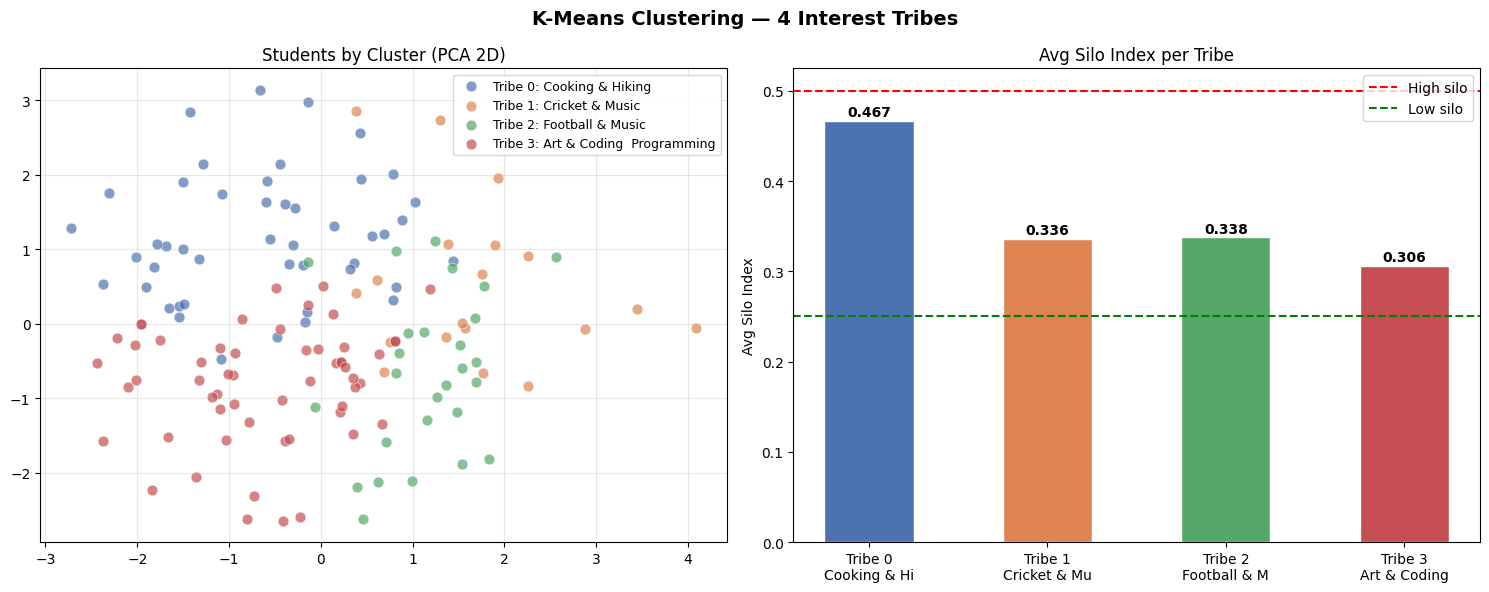

Chart saved: output/cluster_chart.png


In [13]:
X_2d    = pca_vis.transform(X_scaled)
colors  = ["#4C72B0","#DD8452","#55A868","#C44E52"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("K-Means Clustering — 4 Interest Tribes", fontsize=14, fontweight="bold")

for c in range(K):
    mask = combined["Cluster"] == c
    ax1.scatter(X_2d[mask,0], X_2d[mask,1], c=colors[c],
                label=f"Tribe {c}: {cluster_profiles[c]['name']}", alpha=0.7, s=60,
                edgecolors="white", linewidth=0.5)
ax1.set_title("Students by Cluster (PCA 2D)"); ax1.legend(fontsize=9); ax1.grid(alpha=0.3)

avg_silos = [cluster_profiles[c]["avg_silo"] for c in range(K)]
names     = [f"Tribe {c}\n{cluster_profiles[c]['name'][:12]}" for c in range(K)]
bars = ax2.bar(names, avg_silos, color=colors, edgecolor="white", width=0.5)
ax2.axhline(0.5, color="red", linestyle="--", label="High silo")
ax2.axhline(0.25, color="green", linestyle="--", label="Low silo")
ax2.set_title("Avg Silo Index per Tribe"); ax2.set_ylabel("Avg Silo Index"); ax2.legend()
for bar, val in zip(bars, avg_silos):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.005,
             f"{val:.3f}", ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig("output/cluster_chart.png", dpi=150)
plt.show()
print("Chart saved: output/cluster_chart.png")

## Step 13 — Predict a New Student's Tribe

Change the values below and run to test any student.


In [14]:
def predict_student(hobbies, soc_hours, comfort, same_prov_pct, same_fac_pct, friends=4.0):
    """
    hobbies       : list e.g. ["Music", "Gaming"]
    soc_hours     : hours/week in society (0 if not a member)
    comfort       : 1 to 5
    same_prov_pct : % same province friends (0 to 100)
    same_fac_pct  : % same faculty friends (0 to 100)
    friends       : approx. # close friends (same scale as survey `Friends`)
    """
    row = {}
    for h in hobbies_all:
        key = f"h_{h.replace(' ','_').replace('/','').replace(',','')}"
        row[key] = 1 if h in hobbies else 0
    row["SocHours"] = soc_hours
    row["ComfortScore"] = comfort
    _p = float(same_prov_pct) / 100.0
    _f = float(same_fac_pct) / 100.0
    _t = float(friends)
    silo = round(((_p + _f) / 2.0), 3)
    row["Silo_Index"] = float(silo)

    X_new = np.array([[row[c] for c in feature_cols]])
    X_new_sc = scaler.transform(X_new)
    cluster  = int(km_model.predict(X_new_sc)[0])
    # silo already set above from report formula
    lbl      = "Low (diverse) 🟢" if silo < 0.25 else "Moderate 🟡" if silo < 0.5 else "High (siloed) 🔴"

    p = cluster_profiles[cluster]
    print(f"  Tribe    : Tribe {cluster} — {p['name']}")
    print(f"  Silo     : {silo} — {lbl}")
    print(f"  Top hobbies in this tribe: {', '.join(p['top_hobbies'])}")
    if silo > 0.5:
        print("  Recommendation: Join a society or attend a hobby-based mixer!")
    return cluster

# ---- EXAMPLE 1 ----
print("Example 1: Music + Gaming student in society 3hrs/week")
predict_student(hobbies=["Music","Gaming","Coding / Programming"],
                soc_hours=3, comfort=4, same_prov_pct=50, same_fac_pct=60, friends=4.0)

print()

# ---- EXAMPLE 2 ----
print("Example 2: Cricket + Football, no society, mostly same-province friends")
predict_student(hobbies=["Cricket","Football"],
                soc_hours=0, comfort=2, same_prov_pct=80, same_fac_pct=75)


Example 1: Music + Gaming student in society 3hrs/week
  Tribe    : Tribe 3 — Art & Coding  Programming
  Silo     : 0.55 — High (siloed) 🔴
  Top hobbies in this tribe: Art, Coding  Programming, Travelling
  Recommendation: Join a society or attend a hobby-based mixer!

Example 2: Cricket + Football, no society, mostly same-province friends
  Tribe    : Tribe 1 — Cricket & Music
  Silo     : 0.775 — High (siloed) 🔴
  Top hobbies in this tribe: Cricket, Music, Cooking
  Recommendation: Join a society or attend a hobby-based mixer!


1

## Step 14 — Final Summary

In [15]:
print("="*60)
print("GIKI-CONNECT — FINAL RESULTS SUMMARY")
print("="*60)
print(f"  Real responses : {(combined['data_source']=='real').sum()}")
print(f"  Synthetic rows : {(combined['data_source']=='synthetic').sum()}")
print(f"  Total          : {len(combined)}")
print(f"\n  Mean Silo (all)        : {combined['Silo_Index'].mean():.3f}")
print(f"  Mean Silo (members)    : {combined[combined['SocMember']=='Yes']['Silo_Index'].mean():.3f}")
print(f"  Mean Silo (non-members): {combined[combined['SocMember']=='No']['Silo_Index'].mean():.3f}")
print(f"\n  Chi-Square p-value : {p_val:.4f}")
print(f"  Pearson r          : {r_val:.3f}")
print(f"\n  4 Interest Tribes:")
for c in range(K):
    p = cluster_profiles[c]
    print(f"    Tribe {c}: {p['name']:<30} n={p['n']:>3}  silo={p['avg_silo']}")
print("\n  Output files:")
for f in sorted(os.listdir("output")):
    if not os.path.isdir(f"output/{f}"):
        print(f"    output/{f}")
for f in sorted(os.listdir("output/model")):
    print(f"    output/model/{f}")
print("\nDone! All files saved.")

GIKI-CONNECT — FINAL RESULTS SUMMARY
  Real responses : 28
  Synthetic rows : 120
  Total          : 148

  Mean Silo (all)        : 0.366
  Mean Silo (members)    : 0.364
  Mean Silo (non-members): 0.453

  Chi-Square p-value : 1.0000
  Pearson r          : 0.133

  4 Interest Tribes:
    Tribe 0: Cooking & Hiking               n= 46  silo=0.467
    Tribe 1: Cricket & Music                n= 19  silo=0.336
    Tribe 2: Football & Music               n= 27  silo=0.338
    Tribe 3: Art & Coding  Programming      n= 56  silo=0.306

  Output files:
    output/cluster_chart.png
    output/combined_with_clusters.csv
    output/eda_dashboard.png
    output/eda_pie_chart.png
    output/elbow.png
    output/merged_dataset.csv
    output/model/cluster_profiles.json
    output/model/feature_cols.pkl
    output/model/kmeans.pkl
    output/model/pca.pkl
    output/model/scaler.pkl

Done! All files saved.
